In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import lightgbm as lgb
import joblib


In [2]:

df = pd.read_csv(r'../dataset/train.csv')
print(df.columns)
df.shape

Index(['id', 'health_condition', 'sleep_duration', 'heart_rate', 'bmi',
       'calorie_expenditure', 'step_count', 'exercise_duration',
       'water_intake', 'diet_type', 'stress_level', 'sleep_quality',
       'physical_activity_level', 'smoking_alcohol', 'gender'],
      dtype='str')


(690088, 15)

In [3]:
Target= "health_condition"

Features= [
    c for c in df.columns
    if c not in ["id", Target]
]

In [4]:
numeric_cols = [
    "sleep_duration",
    "heart_rate",
    "bmi",
    "calorie_expenditure",
    "step_count",
    "exercise_duration",
    "water_intake"
]

categorical_cols = [
    "diet_type",
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "smoking_alcohol",
    "gender"
]


defined_features = numeric_cols + categorical_cols

# Check count
print("Number of numerical columns:", len(numeric_cols))
print("Number of categorical columns:", len(categorical_cols))
print("Total defined feature columns:", len(defined_features))



Number of numerical columns: 7
Number of categorical columns: 6
Total defined feature columns: 13


In [5]:
medians = {}
for col in numeric_cols:
    med = df[col].median()
    medians[col] = med
    df[col] = df[col].fillna(med)

for col in categorical_cols:
    df[col] = df[col].fillna('missing')

medians

{'sleep_duration': np.float64(6.99),
 'heart_rate': np.float64(75.1),
 'bmi': np.float64(22.99),
 'calorie_expenditure': np.float64(2241.0),
 'step_count': np.float64(8856.0),
 'exercise_duration': np.float64(39.4),
 'water_intake': np.float64(2.17)}

In [6]:
encoders = {}

for col in categorical_cols:
    label_encoder = LabelEncoder()
    df[col] = label_encoder.fit_transform(df[col])

    encoders[col] = label_encoder


y_encoder = LabelEncoder()
df["target_enc"] = y_encoder.fit_transform(df[Target])

print("Target Mapping:")
print(dict(zip(
    y_encoder.classes_,
    y_encoder.transform(y_encoder.classes_)
)))    

Target Mapping:
{'at-risk': np.int64(0), 'fit': np.int64(1), 'unhealthy': np.int64(2)}


In [7]:
x = df[Features]
y = df["target_enc"]


In [8]:
cat_feature_idx = [
    Features.index(col)
    for col in categorical_cols
]

x_train, x_valid, y_train, y_valid = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(x_train.shape)
print(x_valid.shape)





(552070, 13)
(138018, 13)


In [9]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=63,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)


lgb_model.fit(
    x_train,
    y_train,
    eval_set=[(x_valid, y_valid)],
    categorical_feature=cat_feature_idx,
    callbacks=[
        lgb.early_stopping(50),
        lgb.log_evaluation(50)
    ]
)

C:\Users\udnrm\AppData\Roaming\Python\Python313\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.096646 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1814
[LightGBM] [Info] Number of data points in the train set: 552070, number of used features: 13
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Training until validation scores don't improve for 50 rounds
[50]	valid_0's multi_logloss: 0.214314
[100]	valid_0's multi_logloss: 0.187723
[150]	valid_0's multi_logloss: 0.182603
[200]	valid_0's multi_logloss: 0.178889
[250]	valid_0's multi_logloss: 0.175775
[300]	valid_0's multi_logloss: 0.172756
[350]	valid_0's multi_logloss: 0.169812
[400]	valid_0's multi_logloss: 0.167058
[450]	valid_0's multi_logloss: 0.164595
[500]	valid_0's multi_logloss: 0.162025
Did not meet early stopping. Best iteration is:
[500]	valid_0's multi_logloss: 0.162025


,num_leaves,63
,max_depth,8
,learning_rate,0.05
,n_estimators,500
,class_weight,'balanced'
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'
,subsample_for_bin,200000
,objective,None
,min_split_gain,0.0



Accuracy: 94.18%

              precision    recall  f1-score   support

     at-risk       0.99      0.94      0.97    118512
         fit       0.75      0.95      0.83      7961
   unhealthy       0.70      0.96      0.81     11545

    accuracy                           0.94    138018
   macro avg       0.81      0.95      0.87    138018
weighted avg       0.95      0.94      0.95    138018



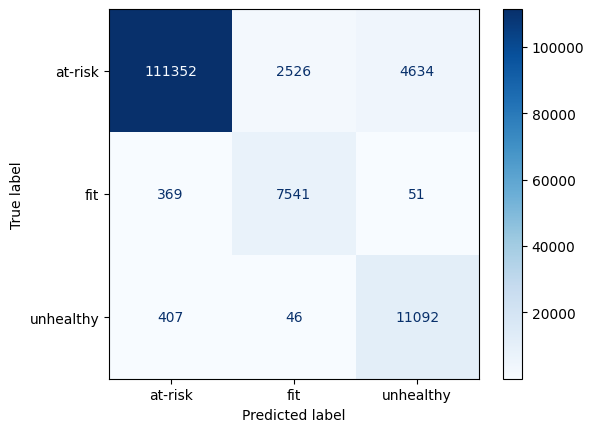

In [10]:

y_pred = lgb_model.predict(x_valid)


accuracy = accuracy_score(y_valid, y_pred)

print(f"\nAccuracy: {accuracy * 100:.2f}%\n")

print(classification_report(
    y_valid,
    y_pred,
    target_names=y_encoder.classes_
))


cm = confusion_matrix(y_valid, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=y_encoder.classes_
)

disp.plot(cmap="Blues")
plt.show()

In [11]:
os.makedirs("models_lgb", exist_ok=True)

joblib.dump(lgb_model, "models_lgb/lgb_model.pkl")
joblib.dump(encoders, "models_lgb/feature_encoders.pkl")
joblib.dump(y_encoder, "models_lgb/target_encoder.pkl")
joblib.dump(Features, "models_lgb/feature_names.pkl")

preprocessing_info = {
    "numeric_columns": numeric_cols,
    "categorical_columns": categorical_cols,
    "numeric_medians": medians,
    "categorical_fill": "missing"
}

joblib.dump(preprocessing_info, "models_lgb/preprocessing_info.pkl")

print("LightGBM artifacts saved successfully!")

LightGBM artifacts saved successfully!


In [12]:

lgb_model = joblib.load("models_lgb/lgb_model.pkl")
encoders = joblib.load("models_lgb/feature_encoders.pkl")
y_encoder = joblib.load("models_lgb/target_encoder.pkl")
Features = joblib.load("models_lgb/feature_names.pkl")
preprocessing_info = joblib.load("models_lgb/preprocessing_info.pkl")

print("Loaded LightGBM model")
print("Expected features:", Features)


test_df = pd.read_csv(r'../dataset/test.csv')


test_ids = test_df["id"]


for col in preprocessing_info["numeric_columns"]:
    median = preprocessing_info["numeric_medians"][col]
    test_df[col] = test_df[col].fillna(median)


for col in preprocessing_info["categorical_columns"]:
    test_df[col] = test_df[col].fillna(
        preprocessing_info["categorical_fill"]
    )


for col in preprocessing_info["categorical_columns"]:

    encoder = encoders[col]
    known_values = set(encoder.classes_)

    test_df[col] = test_df[col].apply(
        lambda x: x if x in known_values else "missing"
    )

    test_df[col] = encoder.transform(test_df[col])


test_df = test_df[Features]


pred_enc = lgb_model.predict(test_df)


predictions = y_encoder.inverse_transform(pred_enc)


submission = pd.DataFrame({
    "id": test_ids,
    "health_condition": predictions
})


os.makedirs("Submissions", exist_ok=True)

submission.to_csv(
    "Submissions/lgb_submission.csv",
    index=False
)

print("LightGBM submission created successfully!")
print(submission.head())
print(submission.shape)

Loaded LightGBM model
Expected features: ['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake', 'diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']
LightGBM submission created successfully!
       id health_condition
0  690088        unhealthy
1  690089        unhealthy
2  690090          at-risk
3  690091          at-risk
4  690092        unhealthy
(295753, 2)
